In [1]:
from 양양_모델 import load_preprocess
import pandas as pd
trains = load_preprocess.trains
tests = load_preprocess.tests

yy_train = trains["wtg_1"]
yy_test = tests["wtg_1"]
target = load_preprocess.target
full_idx = pd.date_range("2024-04-01 01:00:00", "2025-04-01 00:00:00", freq = "1h")
full = pd.DataFrame(index = full_idx)
tg = full.merge(target, right_index= True, left_index= True, how = "left")

all weather & wtg data merged complete!


In [2]:
from 영덕_모델 import load_preprocess
yd_trains = load_preprocess.trains
yd_tests = load_preprocess.tests
yd_target = load_preprocess.target

yd_train = yd_trains["wtg_1"]
yd_test = yd_tests["wtg_1"]
yd_tg = full.merge(yd_target, left_index= True, right_index= True, how = "left")

all weather & wtg data merged complete!


In [3]:
import pandas as pd
import numpy as np

def fill_with_neighbors(
    df, value_col="kwh", fill_target="odd",
    causal=True,   # True면 미래값(nxt) 미사용
    level_agg="sum"  # 일 레벨 산출: 'sum' 또는 'median'
):
    out = df.copy()
    out.index = pd.to_datetime(out.index)
    s = out[value_col].astype(float)

    # 0) 등간격 보장(선택): out = out.asfreq('H')
    # 1) 유일 인덱스(중복 타임스탬프 평균)
    base = s.groupby(s.index).mean()

    # 2) ±1개월 정렬(주의: 위상 어긋남 가능)
    prev = base.copy(); prev.index = prev.index + pd.DateOffset(months=1)
    prev = prev.groupby(prev.index).mean()
    nxt  = base.copy();  nxt.index  = nxt.index  - pd.DateOffset(months=1)
    nxt  = nxt.groupby(nxt.index).mean()

    # 3) 이웃 평균(인과 옵션)
    if causal:
        lookup = prev  # 과거(=원래 시계열 기준 t-1개월)만 사용
    else:
        lookup = pd.concat([prev, nxt], axis=1).mean(axis=1, skipna=True)

    fill_vals = lookup.reindex(out.index)

    # 4) 타깃 마스크
    odd  = pd.Series((out.index.month % 2 == 1), index=out.index)
    nan  = pd.Series(s.isna().to_numpy(), index=out.index)

    if fill_target == "odd":
        target_mask = odd & nan
        neighbor_mask_for_avg = (~odd) & (~s.isna())
    elif fill_target == "even":
        target_mask = (~odd) & nan
        neighbor_mask_for_avg = (odd) & (~s.isna())
    else:
        raise ValueError("fill_target must be 'odd' or 'even'")

    # 5) 1차 채움: ±1개월(또는 과거 1개월) 값
    out[value_col] = out[value_col].where(~target_mask, fill_vals)

    # 6) 레벨(일) × 주간 템플릿(time-of-week)로 2차 보강
    still = target_mask & out[value_col].isna()
    if still.any() and neighbor_mask_for_avg.any():
        s_nei = s[neighbor_mask_for_avg]

        # 6-1) 일 레벨(스케일) 추정 → 날짜 축에서 한쪽 보간
        daily = (s_nei.resample('D').sum() if level_agg == "sum"
                 else s_nei.resample('D').median())
        # 인과 보간: 앞으로만 채우고, 그 외 결측은 마지막값 유지/선형 등 상황에 맞게 선택
        daily_level = daily.copy()
        # 과거만 사용한 선형 외삽 비슷하게: 앞쪽 ffill 후 가벼운 이동평균
        daily_level = daily_level.ffill().rolling(3, min_periods=1).mean()

        # 시간대로 확장(일합→시간 평균/분배)
        level_hourly = daily_level.reindex(pd.to_datetime(out.index.date)).ffill()
        level_hourly = pd.Series(level_hourly.values, index=out.index)
        if level_agg == "sum":
            level_hourly = level_hourly / 24.0

        # 6-2) 주간 템플릿 생성(이웃월 유효구간에서만)
        tiw = (out.index.dayofweek * 24 + out.index.hour)  # 0..167
        tiw_nei = tiw[neighbor_mask_for_avg]
        templ = pd.Series(s_nei.values, index=tiw_nei).groupby(level=0).mean()
        # 정규화(요일별 합=24 또는 평균=1)
        templ = templ / templ.groupby(templ.index // 24).transform('mean')
        templ_full = templ.reindex(range(168)).fillna(1.0)
        templ_series = pd.Series(templ_full.values[tiw], index=out.index)

        # 6-3) 채우기
        out.loc[still, value_col] = (level_hourly.loc[still] * templ_series.loc[still]).values

    return out
# 홀수월만 채움(누출 방지용 인과 모드)
tg_yy = fill_with_neighbors(tg, "energy_kwh", fill_target="odd", causal= False)
tg_yd = fill_with_neighbors(yd_tg, "energy_kwh", fill_target="even", causal= False)

tg_yy = tg_yy.fillna(0)
tg_yd = tg_yd.fillna(0)


In [4]:
tg_yd

,energy_kwh
2024-04-01 01:00:00,8475.0
2024-04-01 02:00:00,12780.0
2024-04-01 03:00:00,19972.0
2024-04-01 04:00:00,17984.0
2024-04-01 05:00:00,12819.0
...,...
2025-03-31 20:00:00,2515.0
2025-03-31 21:00:00,3320.0
2025-03-31 22:00:00,3012.0
2025-03-31 23:00:00,2848.0


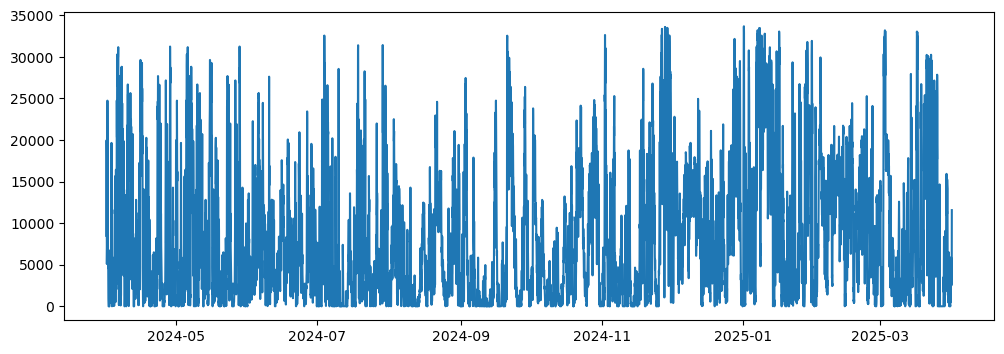

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize= (12,4))
plt.plot(tg_yd.index, tg_yd["energy_kwh"])

In [6]:
import torch
def make_baseline(df, window_size=7):
  df = df.copy()
  df = df.fillna(0)
  df_tmp = df.groupby(df.index.dayofyear).mean()
  df_extended = pd.concat([df_tmp.iloc[-window_size:], df_tmp, df_tmp.iloc[:window_size]])
  df_doy = df_extended.rolling(window=window_size, center=True).mean().iloc[window_size:-window_size]
  df_hour = df.groupby(df.index.hour).mean()
  import torch

  mean = df.mean()
  mean = torch.tensor(df.mean().values, dtype=torch.float)
  mean = mean

  doy_bias = torch.zeros(367)
  doy_bias = doy_bias.unsqueeze(1)
  doy_bias[1:] = torch.tensor(df_doy.values, dtype=torch.float) - mean
  hour_bias = torch.zeros(24)
  hour_bias = hour_bias.unsqueeze(1)
  hour_bias[:] = torch.tensor(df_hour.values, dtype=torch.float) - mean

  def baseline_estimator(doy, hour):
    return mean + doy_bias[doy] + hour_bias[hour]

  df['baseline'] = baseline_estimator(df.index.dayofyear, df.index.hour).numpy()
  return df

baseline_yy = make_baseline(tg_yy, window_size= 31)
baseline_yd = make_baseline(tg_yd, window_size= 31)


In [7]:
def even_data(df):
    yd0 = df.loc["2024-04-01 01:00:00":"2024-05-01 00:00:00"]
    yd1 = df.loc["2024-06-01 01:00:00":"2024-07-01 00:00:00"]
    yd2 = df.loc["2024-08-01 01:00:00":"2024-09-01 00:00:00"]
    yd3 = df.loc["2024-10-01 01:00:00":"2024-11-01 00:00:00"]
    yd4 = df.loc["2024-12-01 01:00:00":"2025-01-01 00:00:00"]
    yd5 = df.loc["2025-02-01 01:00:00":"2025-03-01 00:00:00"]

    baseline = pd.concat([yd0, yd1, yd2, yd3, yd4, yd5], axis=0)
    return baseline

def odd_data(df):
    yy1 = df.loc["2024-05-01 01:00:00":"2024-06-01 00:00:00"]
    yy2 = df.loc["2024-07-01 01:00:00":"2024-08-01 00:00:00"]
    yy3 = df.loc["2024-09-01 01:00:00":"2024-10-01 00:00:00"]
    yy4 = df.loc["2024-11-01 01:00:00":"2024-12-01 00:00:00"]
    yy5 = df.loc["2025-01-01 01:00:00":"2025-02-01 00:00:00"]
    yy6 = df.loc["2025-03-01 01:00:00":"2025-04-01 00:00:00"]

    baseline = pd.concat([yy1, yy2, yy3, yy4, yy5, yy6], axis=0)
    return baseline

yy_baseline_train = even_data(baseline_yy)
yy_baseline_test = odd_data(baseline_yd)
yy_target_train = even_data(tg_yy)

yd_baseline_train = odd_data(baseline_yd)
yd_baseline_test = even_data(baseline_yd)
yd_target_train = odd_data(tg_yd)

In [8]:
bias_yy_train = pd.DataFrame({"energy_kwh": yy_target_train["energy_kwh"] - yy_baseline_train["baseline"]}, index = yy_target_train.index)
bias_yd_train = pd.DataFrame({"energy_kwh": yd_target_train["energy_kwh"] - yd_baseline_train["baseline"]}, index = yd_target_train.index)

bias_yy_train = bias_yy_train.fillna(0)
bais_yd_train = bias_yd_train.fillna(0)

In [9]:
weather_cols = ['dswrf', 'fvmax_50m', 'fvmin_50m',
               'lhnf', 'maxsa_1p5m', 'mcc', 'mgws_0m', 'p', 'pblh', 'pmsl', 'rh_1p5m',
               'sh_1p5m', 'ta', 'ta_1p5m', 'tdp_1p5m', 'usm_5m', 'uws_10m',
               'vsm_5m', 'vws_10m', 'wind_direction_10m', 'wind_direction_5m', 'wind_strength_10m',
               'wind_strength_5m', "vapor_pressure", "abs_fvmax", "abs_fvmin", 'abs_usm_5m', 'abs_uws_10m','abs_vsm_5m', 'abs_vws_10m']

yy_train[['abs_usm_5m', 'abs_uws_10m', 'abs_vsm_5m', 'abs_vws_10m']] = abs(yy_train[['usm_5m', 'uws_10m', 'vsm_5m', 'vws_10m']])
yy_test[['abs_usm_5m', 'abs_uws_10m', 'abs_vsm_5m', 'abs_vws_10m']] = abs(yy_test[['usm_5m', 'uws_10m', 'vsm_5m', 'vws_10m']])

yy_train = yy_train[weather_cols]
yy_test = yy_test[weather_cols]

In [10]:
def make_feature(df_train, df_test):
    import numpy as np

    df_train = df_train.copy()
    df_test = df_test.copy()

# --------------------------
# 기본 날짜 파생 변수 생성
# --------------------------
    df_train["day_of_year"] = df_train.index.day_of_year
    df_test["day_of_year"] = df_test.index.day_of_year

    df_train["day_of_week"] = df_train.index.day_of_week
    df_test["day_of_week"] = df_test.index.day_of_week

    df_train["month_of_year"] = df_train.index.month
    df_test["month_of_year"] = df_test.index.month

    df_train["hour_of_day"] = df_train.index.hour
    df_test["hour_of_day"] = df_test.index.hour

# --------------------------
# 주기 인코딩 (sin / cos)
# --------------------------

# 연간 주기 (365일)
    df_train["sin_doy"] = np.sin(2 * np.pi * df_train["day_of_year"] / 365)
    df_train["cos_doy"] = np.cos(2 * np.pi * df_train["day_of_year"] / 365)

    df_test["sin_doy"] = np.sin(2 * np.pi * df_test["day_of_year"] / 365)
    df_test["cos_doy"] = np.cos(2 * np.pi * df_test["day_of_year"] / 365)

# 주간 주기 (7일)
    df_train["sin_dow"] = np.sin(2 * np.pi * df_train["day_of_week"] / 7)
    df_train["cos_dow"] = np.cos(2 * np.pi * df_train["day_of_week"] / 7)

    df_test["sin_dow"] = np.sin(2 * np.pi * df_test["day_of_week"] / 7)
    df_test["cos_dow"] = np.cos(2 * np.pi * df_test["day_of_week"] / 7)

# 월간 주기 (12개월)
    df_train["sin_moy"] = np.sin(2 * np.pi * df_train["month_of_year"] / 12)
    df_train["cos_moy"] = np.cos(2 * np.pi * df_train["month_of_year"] / 12)

    df_test["sin_moy"] = np.sin(2 * np.pi * df_test["month_of_year"] / 12)
    df_test["cos_moy"] = np.cos(2 * np.pi * df_test["month_of_year"] / 12)

# 일간 주기 (24시간)
    df_train["sin_hod"] = np.sin(2 * np.pi * df_train["hour_of_day"] / 24)
    df_train["cos_hod"] = np.cos(2 * np.pi * df_train["hour_of_day"] / 24)

    df_test["sin_hod"] = np.sin(2 * np.pi * df_test["hour_of_day"] / 24)
    df_test["cos_hod"] = np.cos(2 * np.pi * df_test["hour_of_day"] / 24)


# --------------------------
# day-of-year + hour-of-day 결합
# --------------------------
    df_train["hour_day_year_cos"] = df_train["cos_doy"] + df_train["cos_hod"]
    df_train["hour_day_year_sin"] = df_train["sin_doy"] + df_train["sin_hod"]

    df_test["hour_day_year_cos"] = df_test["cos_doy"] + df_test["cos_hod"]
    df_test["hour_day_year_sin"] = df_test["sin_doy"] + df_test["sin_hod"]

# --------------------------
# day-of-week + hour-of-day 결합
# --------------------------
    df_train["hdw_cos"] = df_train["cos_dow"] + df_train["cos_hod"]
    df_train["hdw_sin"] = df_train["sin_dow"] + df_train["sin_hod"]

    df_test["hdw_cos"] = df_test["cos_dow"] + df_test["cos_hod"]
    df_test["hdw_sin"] = df_test["sin_dow"] + df_test["sin_hod"]

    return df_train, df_test


yy_train, yy_test = make_feature(yy_train, yy_test)
yd_train, yd_test = make_feature(yd_train, yd_test)

In [11]:
yy_train = even_data(yy_train)
yy_test = odd_data(yy_test)

yd_train = odd_data(yd_train)
yd_test = even_data(yd_test)

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(
    yy_train, bias_yy_train, test_size= 0.3, random_state= 42
)

In [13]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)
pred = rf.predict(yy_test)

prediction = pd.DataFrame({"pred":pred}, index = yy_test.index)


c:\Users\yunju\anaconda3\envs\windpower\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


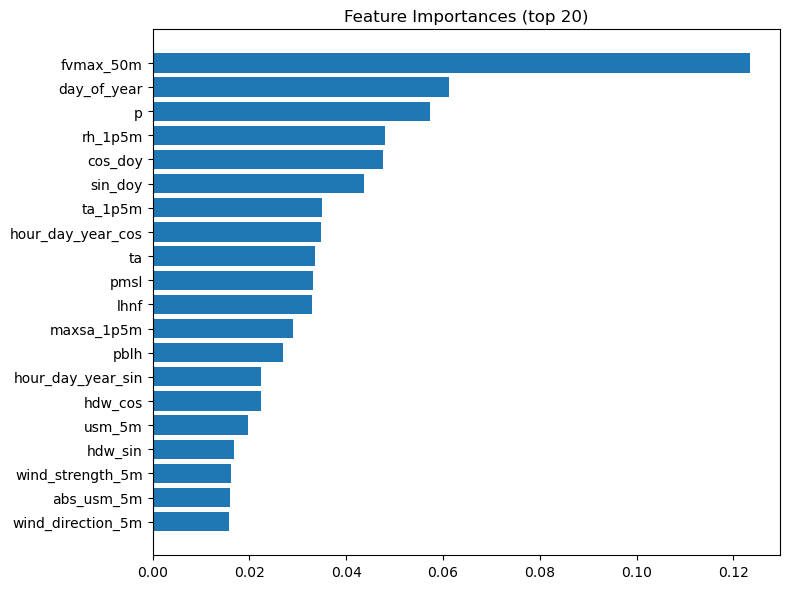

In [14]:
importances = pd.Series(rf.feature_importances_, index=yy_train.columns)\
    .sort_values(ascending=True).tail(20)

plt.figure(figsize=(8,6))
plt.barh(importances.index, importances.values)
plt.title("Feature Importances (top 20)")
plt.tight_layout(); plt.show()

In [15]:
pred_val = rf.predict(X_valid)
prediction_val = pd.DataFrame({"pred": pred_val})

def nmae(target, pred_target):
  mae = abs((target - pred_target))/42000
  nmae1 = mae.mean() * 100
  return nmae1

y_valid.index = prediction_val.index

nmae1 = nmae(y_valid["energy_kwh"], prediction_val["pred"])
print(f"NMAE: {nmae1}")

NMAE: 9.778804463650935


In [16]:
prediction["pred"] = prediction["pred"] + yy_baseline_test["energy_kwh"]
prediction["pred"] = prediction["pred"].clip(lower=0, upper=42000)


In [17]:
yy1 = prediction.loc["2024-05-01 01:00:00":"2024-06-01 00:00:00"]
yy2 = prediction.loc["2024-07-01 01:00:00":"2024-08-01 00:00:00"]
yy3 = prediction.loc["2024-09-01 01:00:00":"2024-10-01 00:00:00"]
yy4 = prediction.loc["2024-11-01 01:00:00":"2024-12-01 00:00:00"]
yy5 = prediction.loc["2025-01-01 01:00:00":"2025-02-01 00:00:00"]
yy6 = prediction.loc["2025-03-01 01:00:00":"2025-04-01 00:00:00"]

yy = pd.concat([yy1, yy2, yy3, yy4, yy5, yy6], axis = 0)

In [ ]:
yy = pd.concat([yy1, yy2, yy3, yy4, yy5, yy6], axis = 0)

yy["plant_name"] = "양양풍력"
yy["start_datetime"] = yy.index - pd.Timedelta(hours = 1)
yy["end_datetime"] = yy.index
yy["yield_kwh"] = yy["pred"] 

yy = yy.drop(["pred"], axis =1)

yy.to_csv("양양_모델/양양_예측/양양_baseline.csv", index = False)
print("양양 예측 저장 위치: 양양_모델/양양_예측/양양_baseline.csv")

yy_prediction saved path: 양양_모델/양양_예측/양양_baseline.csv


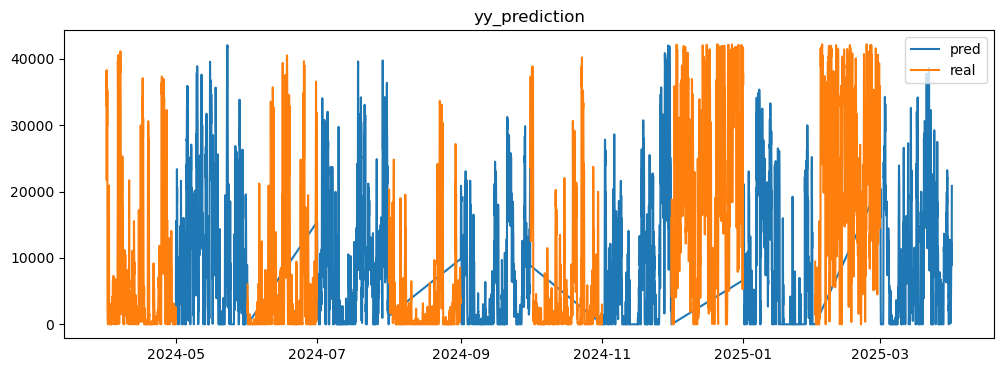

In [19]:
plt.figure(figsize = (12,4))
plt.plot(prediction.index,  prediction, label = "pred")
plt.plot(tg.index, tg, label = "real")
plt.title("yy_prediction")
plt.legend()
plt.show()

In [20]:
yd_train[['abs_usm_5m', 'abs_uws_10m', 'abs_vsm_5m', 'abs_vws_10m']] = abs(yd_train[['usm_5m', 'uws_10m', 'vsm_5m', 'vws_10m']])
yd_test[['abs_usm_5m', 'abs_uws_10m', 'abs_vsm_5m', 'abs_vws_10m']] = abs(yd_test[['usm_5m', 'uws_10m', 'vsm_5m', 'vws_10m']])

yd_train = yd_train[weather_cols]
yd_test = yd_test[weather_cols]

In [21]:
yd_train, yd_test = make_feature(yd_train, yd_test)

In [22]:
from sklearn.model_selection import train_test_split
X_train_yd, X_valid_yd, y_train_yd, y_valid_yd = train_test_split(
    yd_train, bias_yd_train, test_size= 0.3, random_state= 42
)

In [23]:
from sklearn.ensemble import RandomForestRegressor
rf_yd = RandomForestRegressor()
rf_yd.fit(X_train_yd, y_train_yd)

pred_yd = rf_yd.predict(yd_test)
prediction_yd = pd.DataFrame({"pred":pred_yd}, index = yd_baseline_test.index)

c:\Users\yunju\anaconda3\envs\windpower\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [24]:
prediction_yd["pred"] = yd_baseline_test["baseline"] + prediction_yd["pred"]

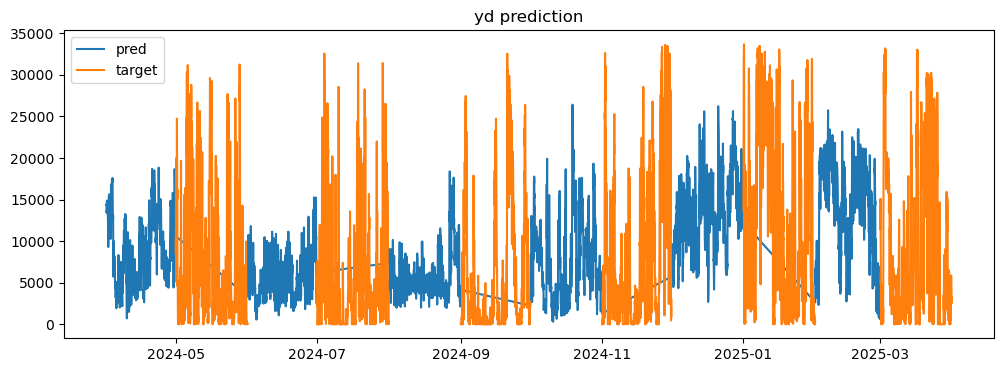

In [25]:
plt.figure(figsize = (12,4))
plt.plot(prediction_yd.index,  prediction_yd, label = "pred")
plt.plot(yd_tg.index, yd_tg, label = "target")
plt.title("yd prediction")
plt.legend()
plt.show()

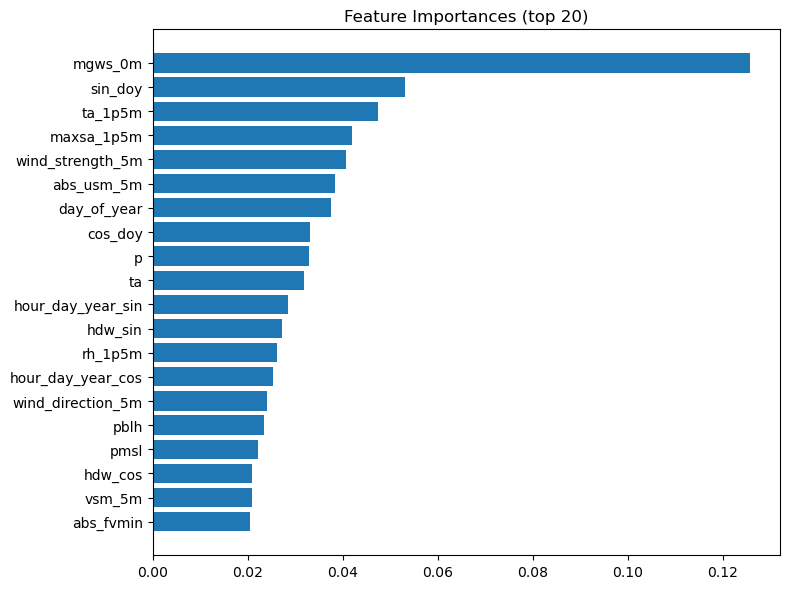

In [26]:
importances_yd = pd.Series(rf_yd.feature_importances_, index=yd_train.columns)\
    .sort_values(ascending=True).tail(20)

plt.figure(figsize=(8,6))
plt.barh(importances_yd.index, importances_yd.values)
plt.title("Feature Importances (top 20)")
plt.tight_layout(); plt.show()

In [27]:
pred_val_yd = rf_yd.predict(X_valid_yd)
prediction_val_yd = pd.DataFrame({"pred": pred_val_yd})

def nmae(target, pred_target):
  mae = abs((target - pred_target))/42000
  nmae1 = mae.mean() * 100
  return nmae1

y_valid_yd.index = prediction_val_yd.index

nmae1 = nmae(y_valid_yd["energy_kwh"], prediction_val_yd["pred"])
print(f"NMAE: {nmae1}")

NMAE: 8.782899953751473


In [28]:
yd0 = prediction_yd.loc["2024-04-01 01:00:00":"2024-05-01 00:00:00"]
yd1 = prediction_yd.loc["2024-06-01 01:00:00":"2024-07-01 00:00:00"]
yd2 = prediction_yd.loc["2024-08-01 01:00:00":"2024-09-01 00:00:00"]
yd3 = prediction_yd.loc["2024-10-01 01:00:00":"2024-11-01 00:00:00"]
yd4 = prediction_yd.loc["2024-12-01 01:00:00":"2025-01-01 00:00:00"]
yd5 = prediction_yd.loc["2025-02-01 01:00:00":"2025-03-01 00:00:00"]

yd = pd.concat([yd0, yd1, yd2, yd3, yd4, yd5], axis=0)

In [ ]:
yd["plant_name"] = "영덕풍력"
yd["start_datetime"] = yd.index - pd.Timedelta(hours=1)
yd["end_datetime"] = yd.index
yd["yield_kwh"] = yd["pred"]

yd = yd.drop(["pred"], axis=1)

yd.to_csv("영덕_모델/영덕_예측/영덕_baseline.csv", index=False)
print("영덕 예측 저장 위치: 영덕_모델/영덕_예측/영덕_baseline.csv")


yd_prediction saved path: 영덕_모델/영덕_예측/영덕_baseline.csv
